## Визуализация результатов

#### Импорты + config

In [6]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import logging
import coloredlogs

PROJECT_ROOT = Path.cwd().parent  # Adjust if needed
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

LOGS_DIR = PROJECT_ROOT / config["paths"]["logs"]
EVAL_PLOTS_DIR = PROJECT_ROOT / config["paths"]["notebooks"] / "eval_plots"
MODEL_PLOTS_DIR = PROJECT_ROOT / config["paths"]["notebooks"] / "model_plots"

logger = logging.getLogger(__name__)
coloredlogs.install(level='INFO', logger=logger)
logger.info("Результаты загружены")

2026-03-06 20:26:11 DESKTOP-1G5G75V __main__[20084] INFO Результаты загружены


#### Метрики из logs (parse last eval.log)

In [7]:
last_eval_log = max(LOGS_DIR.glob("evaluate_*.log"), key=lambda p: p.stat().st_mtime)
with open(last_eval_log, "r") as f:
    lines = f.readlines()

metrics = {}
for line in lines:
    if "ROC-AUC" in line:
        metrics["ROC-AUC"] = float(line.split(":")[-1].strip())
    # Parse similarly for others

logger.info("Метрики: %s", metrics)

2026-03-06 20:26:11 DESKTOP-1G5G75V __main__[20084] INFO Метрики: {'ROC-AUC': 0.9315}


#### Графики (show importance/ROC/PR)

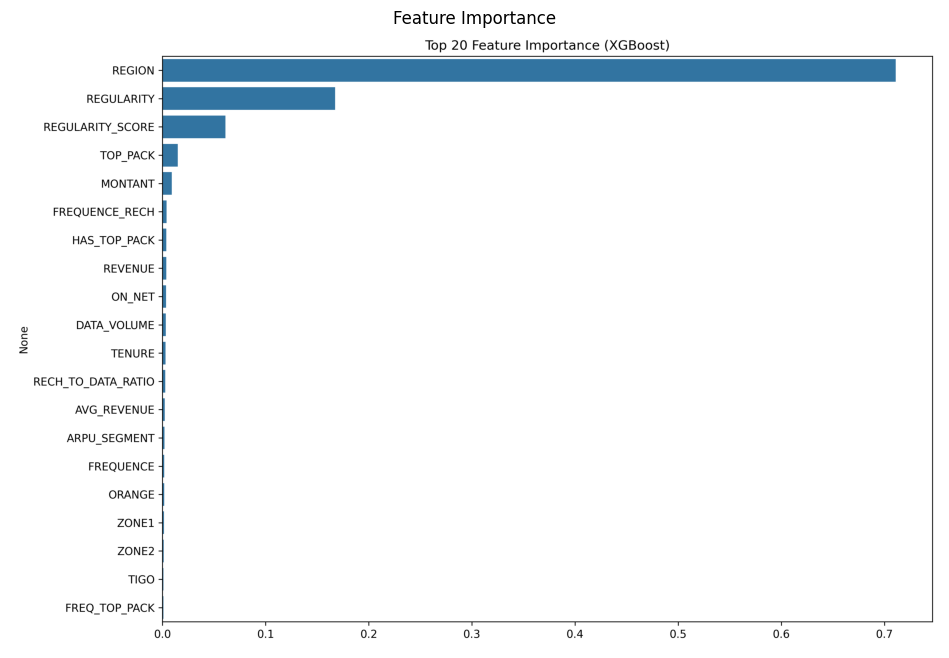

In [8]:
plt.figure(figsize=(12, 8))
plt.imshow(plt.imread(MODEL_PLOTS_DIR / "feature_importance.png"))
plt.axis('off')
plt.title("Feature Importance")
plt.show()

# Similarly for ROC/PR/Confusion from EVAL_PLOTS_DIR

#### Insights + table

In [9]:
import pandas as pd
metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
display(metrics_df)

,Value
ROC-AUC,0.9315
